In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from pathlib import Path
import csv
from scipy.ndimage import label
import math

In [2]:
hexcolors = [
    '#D1B8D7', '#AE76A3', '#882E72',
    '#1965B0', '#5289C7', '#7BAFDE',
    '#4EB265', '#90C987', '#CAE0AB',
    '#F7F056', '#F6C141', '#F1932D',
    '#E8601C', '#DC050C', '#777777'
]
colornames = [
    'purple1', 'purple2', 'purple3',
    'blue1', 'blue2', 'blue3',
    'green1', 'green2', 'green3',
    'yellow1', 'yellow2', 'orange1',
    'orange2', 'red', 'grey'
]
rnb_colors = dict(zip(colornames, hexcolors))
rnb_cmap_cont = LinearSegmentedColormap.from_list("rnb_continuous", hexcolors[::-1], N=256)

plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'font.family': 'sans-serif',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

In [3]:
def parse_probs(filepath):
    """
    Parse DeepTMHMM/TMHMM probability files to extract residue indices 
    and corresponding 'Beta' and 'Membrane' probabilities.
    """
    filepath = Path(filepath)
    indices, beta_probs, mem_probs = [], [], []
    
    beta_idx, mem_idx = 0, 2  # Default fallback offsets

    with filepath.open('r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Dynamically determine column layout from header
            if line.startswith('#'):
                if line.startswith('#AA,'):
                    headers = line[1:].split(',')
                    beta_idx = headers.index('Beta') - 1
                    mem_idx = headers.index('Membrane') - 1
                continue

            # Split by whitespace first to isolate residue index
            parts = line.split()
            res_idx = int(parts[0])
            
            # The remaining payload contains comma-separated values (and possibly amino acid letter)
            remainder = "".join(parts[1:]).split(',')
            
            # Extract only numeric probability values, stripping any non-numeric fields (e.g. 'S')
            probs = []
            for item in remainder:
                try:
                    probs.append(float(item))
                except ValueError:
                    continue  # Skips amino acid letter or non-float tokens

            indices.append(res_idx)
            beta_probs.append(probs[beta_idx])
            mem_probs.append(probs[mem_idx])

    return np.array(indices), np.array(beta_probs), np.array(mem_probs)

def protein_category(protein_name):
    if protein_name in single_pass:
        return 'Single-pass TMD'
    elif protein_name in multi_pass_alpha:
        return 'Multi-pass (α-helical)'
    elif protein_name in multi_pass_beta:
        return 'Multi-pass (β-barrel)'
    else:
        return None

In [4]:
proteins = [
    'hGHR', 'EGFR', 'LAT', 'CD247', 'ADRA2A', 'RHO', 'TRPV4', 'ompA', 
    'TOMM40', 'VDAC1', 'bamA', '2MJO', '1A91', '5CFB', '5VPN', '5XU1', 
    '8TOL', '4IKV', '1BT9', '1EK9', '4K3B'
]
omegas = ['100', '110', '120'] # stand for 1.0 nm, 1.1 nm and 1.2 nm respectively
runs = ['0', '1', '2', '3', '4', '5']
window_size = 5

single_pass = ['CD247', 'EGFR', 'LAT', 'hGHR']
multi_pass_alpha = ['ADRA2A', 'RHO', 'TRPV4', '1A91', '3RKO', '4IKV', '5CFB', '5VPN', '5XU1', '8TOL', '2MJO']
multi_pass_beta = ['TOMM40', 'VDAC1', 'bamA', 'ompA', '1BT9', '1EK9', '4K3B']

category_colors = {
    'Single-pass TMD': rnb_colors['blue2'],
    'Multi-pass (α-helical)': rnb_colors['orange2'],
    'Multi-pass (β-barrel)': rnb_colors['green1'],
}

chosen_axes = {
    'LAT': {'100': 0, '110': 0, '120': 0}, 
    'RHO': {'100': 1, '110': 1, '120': 1},
    'TRPV4': {'100': 1, '110': 1, '120': 1}, 
    'ADRA2A': {'100': 0, '110': 0, '120': 0},
    'CD247': {'100': 0, '110': 0, '120': 0}, 
    'EGFR': {'100': 0, '110': 0, '120': 0},
    'TOMM40': {'100': 2, '110': 2, '120': 2}, 
    'VDAC1': {'100': 2, '110': 2, '120': 2},
    'bamA': {'100': 2, '110': 2, '120': 2}, 
    'ompA': {'100': 0, '110': 0, '120': 0},
    'hGHR': {'100': 0, '110': 0, '120': 0}, 
    '1A91': {'100': 0, '110': 0, '120': 0},
    '1BT9': {'100': 2, '110': 2, '120': 2}, 
    '1EK9': {'100': 2, '110': 2, '120': 2},
    '2MJO': {'100': 1, '110': 1, '120': 1}, 
    '3RKO': {'100': 2, '110': 2, '120': 2},
    '4IKV': {'100': 2, '110': 2, '120': 2}, 
    '4K3B': {'100': 2, '110': 2, '120': 2},
    '5CFB': {'100': 2, '110': 2, '120': 2}, 
    '5VPN': {'100': 1, '110': 1, '120': 1},
    '5XU1': {'100': 1, '110': 1, '120': 1}, 
    '8TOL': {'100': 2, '110': 2, '120': 2}
}

chosen_mempro_rank = {
    'LAT': 2, 'RHO': 0, 'TRPV4': 0, 'ADRA2A': 0, 'CD247': 2, 'EGFR': 0,
    'TOMM40': 0, 'VDAC1': 0, 'bamA': 0, 'ompA': 0, 'hGHR': 0, '1A91': 0,
    '1BT9': 0, '1EK9': 0, '2MJO': 0, '3RKO': 0, '4IKV': 0, '4K3B': 0,
    '5CFB': 0, '5VPN': 0, '5XU1': 0, '8TOL': 0
}

mempro_ranks = {p: [0, 1, 2] for p in proteins}

## Figure 3A

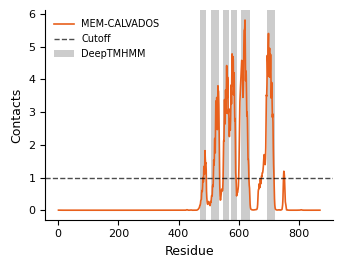

In [5]:
protein = 'TRPV4'
omega = '110'
window_size = 5

profile_file = f'data/omega_scan/{protein}_{omega}_1d_cmap.npy'
profile_raw = np.load(profile_file)

profile = np.convolve(profile_raw, np.ones(window_size) / window_size, mode='same')
x_a = np.arange(1, len(profile) + 1)

probs_path = f'data/omega_scan/DeepTMHMM_results/{protein}_probs.csv'

tmhmm_bin = None
if os.path.exists(probs_path):
    tmhmm_dist, beta_prob, mem_prob = parse_probs(probs_path)
    chosen = np.maximum(beta_prob, mem_prob)
    idx0 = tmhmm_dist - (1 if tmhmm_dist.min() == 1 and tmhmm_dist.max() == len(profile) else 0)
    tmhmm_prob = np.full(len(profile), np.nan)
    valid = (idx0 >= 0) & (idx0 < len(profile))
    tmhmm_prob[idx0[valid]] = chosen[valid]
    tmhmm_bin = np.nan_to_num(tmhmm_prob, nan=0.0) >= 0.5

fig, ax = plt.subplots(figsize=(3.5, 2.75))

ax.plot(x_a, profile, color=rnb_colors['orange2'], lw=1.2, label='MEM-CALVADOS')
ax.axhline(1.0, color='k', ls='--', lw=1.0, alpha=0.7, label='Cutoff')
ax.set_xlabel('Residue')
ax.set_ylabel('Contacts')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

if tmhmm_bin is not None:
    tmd, num_tmd = label(tmhmm_bin)
    for domain_idx in range(1, num_tmd + 1):
        indices = np.where(tmd == domain_idx)[0]
        lbl = 'DeepTMHMM' if domain_idx == 1 else ""
        ax.axvspan(x_a[indices[0]], x_a[indices[-1]], color='k', alpha=0.2, lw=0, label=lbl)

ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

## Figure 3B

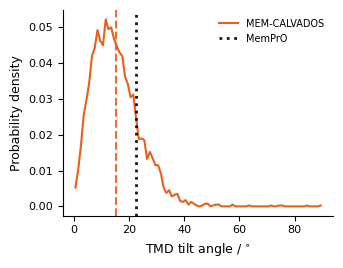

In [6]:
protein = 'TRPV4'
omega = '110'

k = chosen_axes[protein][omega]
angle_file = f'data/omega_scan/{protein}_{omega}_domain_angles.npy'

fig, ax = plt.subplots(figsize=(3.5, 2.75))

if os.path.exists(angle_file):
    all_tmd = np.load(angle_file)
    angles_pooled = all_tmd[:, k]
    
    bins = np.arange(np.floor(angles_pooled.min()), np.ceil(angles_pooled.max()) + 1.0, 1.0)
    x_b = bins[:-1] + 0.5
    hist = np.histogram(angles_pooled, bins=bins, density=True)[0]
    mean_sim = np.mean(angles_pooled)

    csvfile = f'data/omega_scan/MemPrO_results/{protein}_tmd_tilt.csv'
    mempro_angle = np.nan
    if os.path.exists(csvfile):
        mempro_result = pd.read_csv(csvfile)
        rank_idx = chosen_mempro_rank[protein]
        rank_list = mempro_ranks[protein]
        if rank_idx < len(rank_list):
            iloc_idx = rank_list[rank_idx]
            if iloc_idx < len(mempro_result):
                mempro_angle = mempro_result.iloc[iloc_idx][f'angle_axis{k}']

    ax.plot(x_b, hist, lw=1.5, color=rnb_colors['orange2'], label='MEM-CALVADOS')
    ax.axvline(mean_sim, color=rnb_colors['orange2'], ls='--', lw=1.5, alpha=0.9)
    if not np.isnan(mempro_angle):
        ax.axvline(mempro_angle, color='k', ls=':', lw=2, alpha=0.9, label='MemPrO')

ax.set_xlabel('TMD tilt angle / $^{\circ}$')
ax.set_ylabel('Probability density')
ax.legend(loc='upper right', frameon=False, fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Figure 3C

In [7]:
cutoff = [1.0]
window_size = 5

iou_results = []

for protein in proteins:
    probs_path = f'data/omega_scan/DeepTMHMM_results/{protein}_probs.csv'
    if not os.path.exists(probs_path):
        continue
    tmhmm_dist, beta_prob, mem_prob = parse_probs(probs_path)
    chosen_prob = np.maximum(beta_prob, mem_prob)

    for omega in omegas:
        profile_file = f'data/omega_scan/{protein}_{omega}_1d_cmap.npy'
        if not os.path.exists(profile_file):
            continue

        profile_raw = np.load(profile_file)
        profile = np.convolve(profile_raw, np.ones(window_size) / window_size, mode='same')
        N = len(profile)

        idx0 = tmhmm_dist.copy()
        if idx0.min() == 1 and idx0.max() == N:
            idx0 = idx0 - 1
            
        tmhmm_prob = np.full(N, np.nan)
        valid = (idx0 >= 0) & (idx0 < N)
        tmhmm_prob[idx0[valid]] = chosen_prob[valid]
        tmhmm_bin = np.nan_to_num(tmhmm_prob, nan=0.0) >= 0.5

        for c in cutoff:
            profile_bin = profile >= c
            
            intersection = np.logical_and(profile_bin, tmhmm_bin).sum()
            union = np.logical_or(profile_bin, tmhmm_bin).sum()
            
            iou = intersection / union if union > 0 else 0.0
            iou_results.append((protein, omega, f'cutoff {c:.1f}', iou))

iou_df = pd.DataFrame(iou_results, columns=['Protein', 'Omega', 'Cutoff', 'IoU'])
iou_df

,Protein,Omega,Cutoff,IoU
0,hGHR,100,cutoff 1.0,0.677419
1,hGHR,110,cutoff 1.0,0.488372
2,hGHR,120,cutoff 1.0,0.420000
3,EGFR,100,cutoff 1.0,0.916667
4,EGFR,110,cutoff 1.0,0.785714
...,...,...,...,...
58,1EK9,110,cutoff 1.0,0.206667
59,1EK9,120,cutoff 1.0,0.327044
60,4K3B,100,cutoff 1.0,0.270270
61,4K3B,110,cutoff 1.0,0.290000


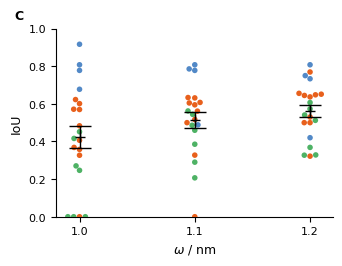

In [8]:
single_pass = ['CD247', 'EGFR', 'LAT', 'hGHR']
multi_pass_alpha = ['ADRA2A', 'RHO', 'TRPV4', '1A91', '4IKV', '5CFB', '5VPN', '5XU1', '8TOL', '2MJO']
multi_pass_beta = ['TOMM40', 'VDAC1', 'bamA', 'ompA', '1BT9', '1EK9', '4K3B']


df_iou = pd.DataFrame(iou_results, columns=['Protein', 'Omega', 'Cutoff', 'IoU'])
subset_c = df_iou[df_iou['Cutoff'] == 'cutoff 1.0'].copy()
subset_c['Omega'] = subset_c['Omega'].astype(str)
subset_c['Category'] = subset_c['Protein'].map(protein_category)

# Drop any unassigned protein rows gracefully
subset_c = subset_c.dropna(subset=['Category'])

# Compute mean and SE across omega conditions
avg_c = subset_c.groupby('Omega')['IoU'].mean().reset_index().sort_values('Omega')
se_c = subset_c.groupby('Omega')['IoU'].sem().reset_index().sort_values('Omega')

x_order_c = sorted(subset_c['Omega'].unique(), key=float)
x_pos_c = [x_order_c.index(o_) for o_ in avg_c['Omega']]

# --- Panel C Plotting ---
fig, ax = plt.subplots(figsize=(3.5, 2.75))

sns.swarmplot(
    data=subset_c, x='Omega', y='IoU', hue='Category',
    palette=category_colors, hue_order=list(category_colors.keys()),
    size=4, ax=ax
)
ax.errorbar( x_pos_c, avg_c['IoU'].values, yerr=se_c['IoU'].values, fmt='+', color='k', mfc='none', mec='k', mew=1, ms=7, lw=1, elinewidth=1, capsize=8, zorder=5, label='mean ± SE')

ax.set_xlabel('$\omega$ / nm')
ax.set_ylabel('IoU')
ax.set_ylim(0, 1)

xticks = {'100': 1.0, '110': 1.1, '120': 1.2}
ax.set_xticks(range(len(xticks)))
ax.set_xticklabels([f"{val:.1f}" for val in xticks.values()])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-0.15, 1.05, 'C', transform=ax.transAxes, fontweight='bold')
ax.legend().remove()  # Legend shared with Panel D in full figure layout

plt.tight_layout()
plt.show()

## Figure 3D

In [9]:
mempro_records = []

for protein in proteins:
    mempro_result = f'data/omega_scan/MemPrO_results/{protein}_tmd_tilt.csv'
    dfm = pd.read_csv(mempro_result) if os.path.exists(mempro_result) else None

    for omega in omegas:
        angle_file = f'data/omega_scan/{protein}_{omega}_domain_angles.npy'
        if not os.path.exists(angle_file):
            continue

        all_tmd = np.load(angle_file)
        
        k = chosen_axes[protein][omega]
        rank_idx = chosen_mempro_rank[protein]

        chosen_angles = all_tmd[:, k]
        mean_sim = np.mean(chosen_angles)

        mempro_angle = np.nan
        if dfm is not None:
            rank_list = mempro_ranks[protein]
            if rank_idx < len(rank_list):
                iloc_idx = rank_list[rank_idx]
                if iloc_idx < len(dfm):
                    mempro_angle = dfm.iloc[iloc_idx][f'angle_axis{k}']

        mempro_records.append({
            'protein': protein,
            'omega': omega,
            'axis_idx': k,
            'mean_sim': mean_sim,
            'mempro_angle': mempro_angle
        })

df_mempro = pd.DataFrame(mempro_records)

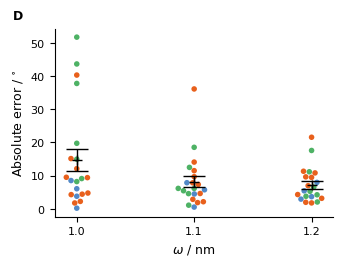

In [10]:
df_plot = df_mempro.copy()
df_plot = df_plot.dropna(subset=['mean_sim', 'mempro_angle']).copy()
df_plot['mae'] = (df_plot['mean_sim'] - df_plot['mempro_angle']).abs()
df_plot['Category'] = df_plot['protein'].map(protein_category)

df_plot['omega'] = pd.Categorical(df_plot['omega'].astype(str), categories=omegas, ordered=True)

mae_summary = (
    df_plot.groupby('omega', observed=False)
    .agg(mae=('mae', 'mean'),
         std_err=('mae', lambda v: v.std(ddof=1) / np.sqrt(v.notna().sum())))
)
x_d = np.arange(3)

# 2. Plotting
fig, ax = plt.subplots(figsize=(3.5, 2.75))

sns.swarmplot(
    data=df_plot, x='omega', y='mae', hue='Category',
    palette=category_colors, hue_order=list(category_colors.keys()),
    size=4, ax=ax
)

# Corrected errorbar signature: (x, y, yerr)
ax.errorbar(
    x_d,
    mae_summary['mae'].values,
    yerr=mae_summary['std_err'].values,
    fmt='+',
    color='k',
    mfc='none',
    mec='k',
    mew=1,
    ms=7,
    lw=1,
    elinewidth=1,
    capsize=8,
    zorder=5,
    label='mean ± SE'
)

ax.set_xlabel('$\omega$ / nm')
ax.set_ylabel('Absolute error / $^{\circ}$')

xticks = {'100': 1.0, '110': 1.1, '120': 1.2}
ax.set_xticks(range(len(xticks)))
ax.set_xticklabels([f"{val:.1f}" for val in xticks.values()])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-0.15, 1.05, 'D', transform=ax.transAxes, fontweight='bold')
ax.get_legend().remove()  


plt.tight_layout()
plt.show()

## Figures S6-10

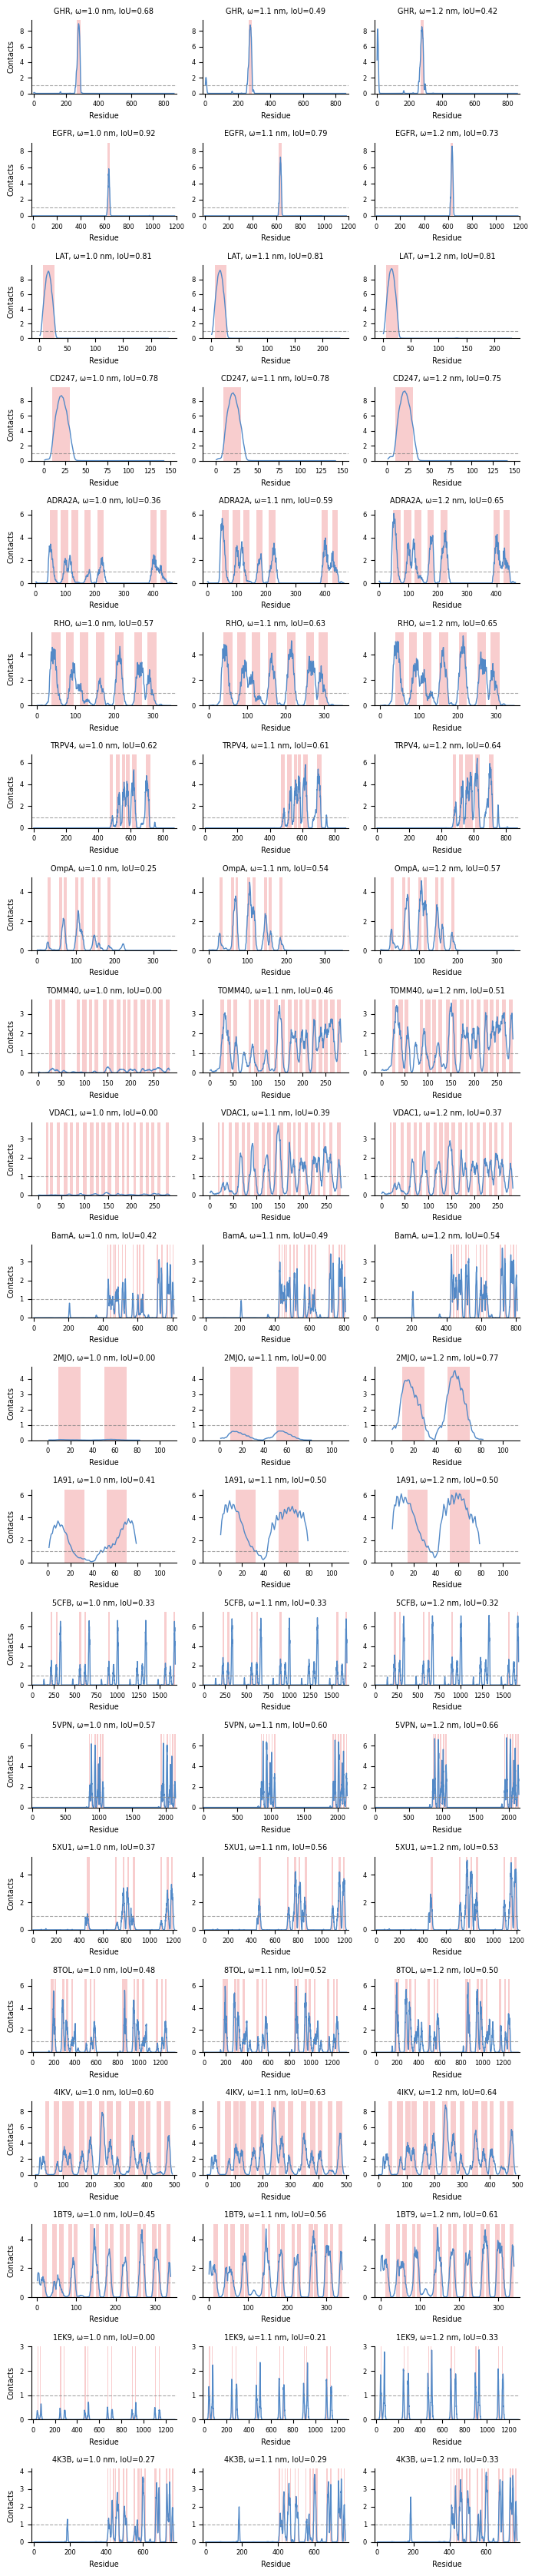

In [11]:
window_size = 5
omega_labels = {'100': '1.0', '110': '1.1', '120': '1.2'}

protein_display = {
    'hGHR': 'GHR', 'EGFR': 'EGFR', 'LAT': 'LAT', 'CD247': 'CD247',
    'ADRA2A': 'ADRA2A', 'RHO': 'RHO', 'TRPV4': 'TRPV4', 'ompA': 'OmpA',
    'TOMM40': 'TOMM40', 'VDAC1': 'VDAC1', 'bamA': 'BamA', '2MJO': '2MJO',
    '1A91': '1A91', '5CFB': '5CFB', '5VPN': '5VPN', '5XU1': '5XU1',
    '8TOL': '8TOL', '4IKV': '4IKV', '1BT9': '1BT9', '1EK9': '1EK9', '4K3B': '4K3B'
}

iou_dict = iou_df.set_index(['Protein', 'Omega'])['IoU'].to_dict()

panels = []
protein_ylims = {}
protein_xlims = {}

for p in proteins:
    probs_path = f'data/omega_scan/DeepTMHMM_results/{p}_probs.csv'
    tmhmm_bin = None
    if os.path.exists(probs_path):
        tmhmm_dist, beta_prob, mem_prob = parse_probs(probs_path)
        chosen_prob = np.maximum(beta_prob, mem_prob)
    
    p_ymax = 0
    p_xmax = 100

    for o in omegas:
        profile_file = f'data/omega_scan/{p}_{o}_1d_cmap.npy'
        profile_raw = np.load(profile_file)
        profile = np.convolve(profile_raw, np.ones(window_size) / window_size, mode='same')
        x = np.arange(1, len(profile) + 1)
        
        N = len(profile)
        idx0 = tmhmm_dist.copy()
        if idx0.min() == 1 and idx0.max() == N:
            idx0 -= 1
        tmhmm_prob = np.full(N, np.nan)
        valid = (idx0 >= 0) & (idx0 < N)
        tmhmm_prob[idx0[valid]] = chosen_prob[valid]
        tmhmm_bin = np.nan_to_num(tmhmm_prob, nan=0.0) >= 0.5

        iou_val = iou_dict.get((p, o), np.nan)
        p_ymax = max(p_ymax, profile.max())
        p_xmax = max(p_xmax, x.max())

        panels.append({
            "protein": p, "omega": o, "x": x, "profile": profile,
            "tmhmm_bin": tmhmm_bin, "iou": iou_val, "missing": False
        })
        
    protein_ylims[p] = (0, p_ymax * 1.05 if p_ymax > 0 else 1)
    protein_xlims[p] = (-15, p_xmax + 15)


ncols = 3
nrows = 21
fig, axes = plt.subplots(nrows, ncols, figsize=(7, 1.6 * nrows), squeeze=False)

for i, panel in enumerate(panels):
    ax = axes[i // ncols, i % ncols]
    
    if panel.get("missing", False):
        ax.axis('off')
        continue

    is_first = (i % len(omegas) == 0)

    disp_name = protein_display.get(panel["protein"], panel["protein"])
    title = f'{disp_name}, ω={omega_labels.get(panel["omega"], panel["omega"])} nm, IoU={panel["iou"]:.2f}'

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xlim(protein_xlims[panel["protein"]])
    ax.set_ylim(protein_ylims[panel["protein"]])
    ax.set_title(title, fontsize=7)

    ax.plot(panel["x"], panel["profile"], color=rnb_colors['blue2'], lw=1.0)
    ax.axhline(1.0, color='grey', ls='--', lw=0.8, alpha=0.7)
    ax.set_xlabel('Residue', fontsize=7)
    ax.tick_params(labelsize=6)
    
    if panel["tmhmm_bin"] is not None:
        mask = panel["tmhmm_bin"]
        x_arr = panel["x"]
        in_span = False
        start = None
        for idx, val in enumerate(mask):
            if val and not in_span:
                start = x_arr[idx]
                in_span = True
            elif not val and in_span:
                ax.axvspan(start - 0.5, x_arr[idx - 1] + 0.5, color=rnb_colors['red'], alpha=0.2, lw=0)
                in_span = False
        if in_span:
            ax.axvspan(start - 0.5, x_arr[-1] + 0.5, color=rnb_colors['red'], alpha=0.2, lw=0)

    if is_first:
        ax.set_ylabel('Contacts', fontsize=7)


# Hide trailing unused subplots
for j in range(len(panels), nrows * ncols):
    axes[j // ncols, j % ncols].axis('off')

plt.tight_layout()
plt.show()

## Figures S11-17

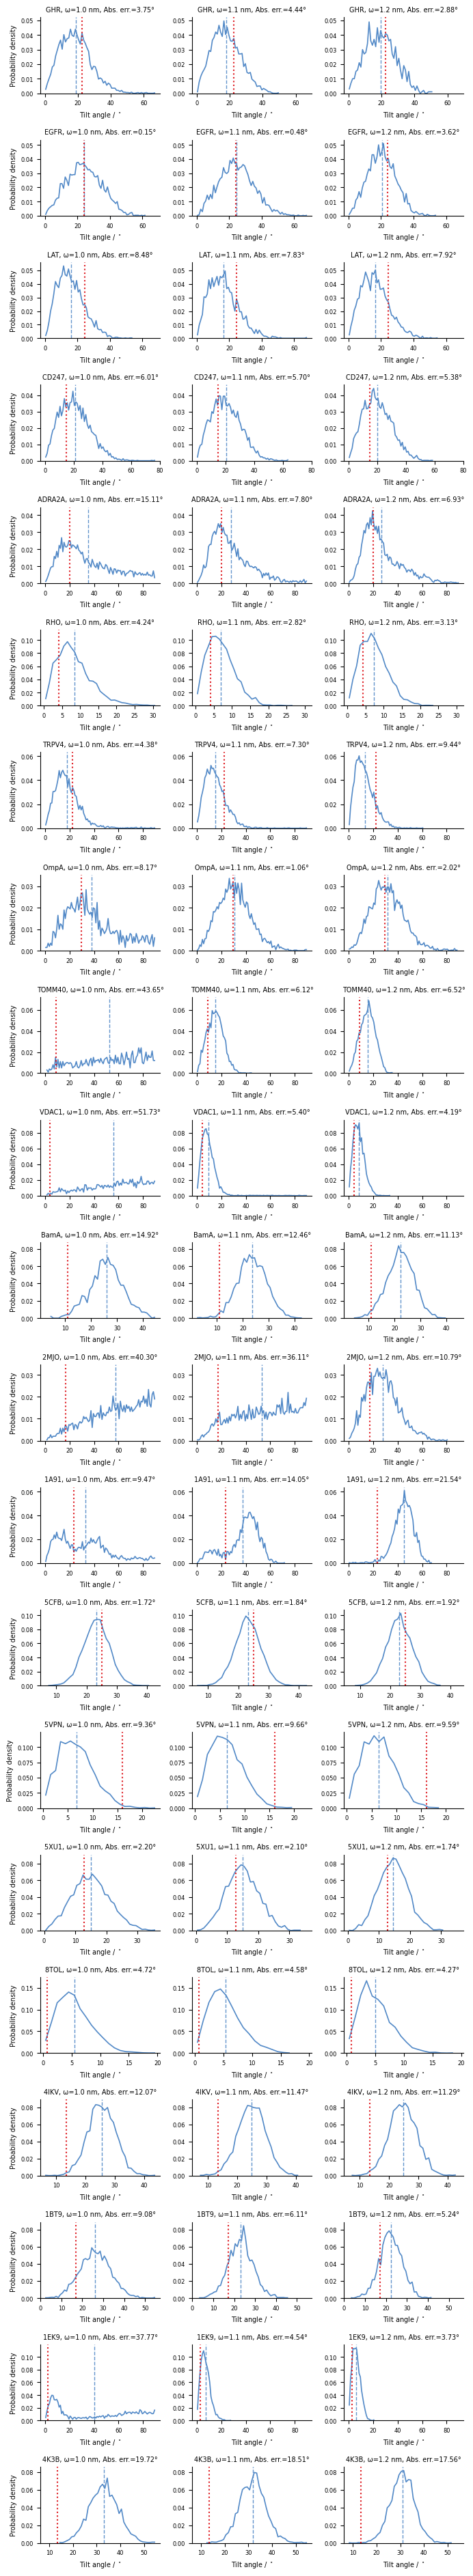

In [12]:
mempro_dict = df_mempro.set_index(['protein', 'omega'])[['mean_sim', 'mempro_angle', 'axis_idx']].to_dict('index')

panels = []
protein_ylims = {}
protein_xlims = {}
bin_width = 1.0

for p in proteins:
    p_ymax = 0
    p_xmin = 180.0
    p_xmax = 0.0
    has_data = False

    for o in omegas:
        data = mempro_dict.get((p, o))
        angle_file = f'data/omega_scan/{p}_{o}_domain_angles.npy'

        k = int(data['axis_idx'])
        all_tmd = np.load(angle_file)
        angles = all_tmd[:, k]

        amin, amax = np.floor(angles.min()), np.ceil(angles.max())
        bins = np.arange(amin, amax + bin_width, bin_width)
        x = bins[:-1] + bin_width / 2
        hist = np.histogram(angles, bins=bins, density=True)[0]

        p_ymax = max(p_ymax, hist.max())
        p_xmin = min(p_xmin, x.min())
        p_xmax = max(p_xmax, x.max())
        has_data = True

        panels.append({
            "protein": p, "omega": o, "x": x, "hist": hist,
            "mean_sim": data['mean_sim'], "mempro_angle": data['mempro_angle'],
            "missing": False
        })

        pad = (p_xmax - p_xmin) * 0.05 if p_xmax > p_xmin else 1.0
        protein_ylims[p] = (0, p_ymax * 1.05)
        protein_xlims[p] = (p_xmin - pad, p_xmax + pad)


ncols = 3
nrows = math.ceil(len(panels) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(7, 1.8 * nrows), squeeze=False)

for i, panel in enumerate(panels):
    ax = axes[i // ncols, i % ncols]
    is_first = (i % len(omegas) == 0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    disp_name = protein_display.get(panel["protein"], panel["protein"])
    
    if panel["protein"] in protein_xlims:
        ax.set_xlim(protein_xlims[panel["protein"]])
        ax.set_ylim(protein_ylims[panel["protein"]])

    ax.plot(panel["x"], panel["hist"], lw=1.2, color=rnb_colors['blue2'])
    ax.axvline(panel["mean_sim"], color=rnb_colors['blue2'], ls='--', lw=1.0, alpha=0.9)

    ax.axvline(panel["mempro_angle"], color=rnb_colors['red'], ls=':', lw=1.5, alpha=0.9)

    ax.set_xlabel('Tilt angle / $^\circ$', fontsize=7)
    ax.tick_params(labelsize=6)
    abs_err = abs(panel["mean_sim"] - panel["mempro_angle"]) if not np.isnan(panel["mempro_angle"]) else np.nan
    ax.set_title(f'{disp_name}, ω={omega_labels.get(panel["omega"], panel["omega"])} nm, Abs. err.={abs_err:.2f}°', fontsize=7)

    if is_first:
        ax.set_ylabel('Probability density', fontsize=7)



plt.tight_layout()
plt.show()